# Verificación — Spark lee tu datalake

**Curso:** ST1630-2026-2 · **Semana:** S4-S5
**Estudiante:** Mateo García, Juan José Gómez, Juan José Vargas y Luis Moreno
**Fecha:** _13/08/2026_

## Objetivo

Cerrar el Lab 1a confirmando que tu clúster EMR puede leer el datalake
que construiste (Partes 1-4): conectar Spark a tu bucket S3, leer el
archivo Parquet de Bronze, y repetir el benchmark Parquet vs. CSV visto
en la clase de S4.

**Qué debe verse al final para confirmar que el lab está completo:**
- La Celda 2 muestra el schema y 5 filas del Parquet leído desde S3
  (si esto funciona, tu bucket, tu rol IAM y tu clúster están bien
  configurados de punta a punta).
- La Celda 3 imprime el tiempo de una misma consulta en Parquet y en
  CSV, y el ratio entre ambos.
- Completaste el análisis de la Celda 4 y capturaste el DAG de Spark UI
  como indica la Celda 5.

In [3]:
from pyspark.sql import SparkSession
from pyspark.sql import functions as F

# getOrCreate() funciona tanto en EMR (donde ya existe una sesión activa
# administrada por el clúster) como en un entorno local con pyspark
# instalado, sin necesitar ramas de código distintas.
spark = SparkSession.builder.appName("ST1630-Lab1a-Verificacion").getOrCreate()

# EDITAR: reemplaza por el bucket que creaste en setup_s3.sh
# (convención: st1630-{tu-usuario}-{año})
BUCKET = "st1630-mgarciac10-2026"

# En EMR, S3 se referencia directamente con el esquema s3://.
# En local (con las credenciales de AWS Academy exportadas), la misma
# ruta también funciona porque Spark usa el conector S3A por debajo.
ruta_parquet = f"s3://{BUCKET}/bronze/ventas/prueba_parquet.parquet"
ruta_csv = f"s3://{BUCKET}/bronze/ventas/prueba_csv.csv"

df_parquet = spark.read.parquet(ruta_parquet)

df_parquet.printSchema()
df_parquet.show(5, truncate=False)

# Si ves el schema y las filas de arriba, tu datalake funciona
# correctamente de punta a punta: bucket, permisos IAM y clúster EMR.
print("Filas leídas:", df_parquet.count())

root
 |-- order_id: string (nullable = true)
 |-- fecha: string (nullable = true)
 |-- region: string (nullable = true)
 |-- producto: string (nullable = true)
 |-- categoria: string (nullable = true)
 |-- cantidad: long (nullable = true)
 |-- precio_unit: double (nullable = true)
 |-- total: double (nullable = true)
 |-- canal: string (nullable = true)
 |-- devuelto: boolean (nullable = true)

+----------+----------+------------+---------+-----------+--------+-----------+---------+------+--------+
|order_id  |fecha     |region      |producto |categoria  |cantidad|precio_unit|total    |canal |devuelto|
+----------+----------+------------+---------+-----------+--------+-----------+---------+------+--------+
|ORD-000001|2026-04-22|Cali        |Mouse    |Electrónica|1       |789300.0   |789300.0 |online|false   |
|ORD-000002|2026-03-22|Barranquilla|Gorra    |Ropa       |2       |57000.0    |114000.0 |tienda|false   |
|ORD-000003|2026-01-06|Bogotá      |Zapatos  |Ropa       |4       |16380

In [4]:
import time

df_csv = spark.read.option("header", "true").option("inferSchema", "true").csv(ruta_csv)

# Misma consulta sobre ambos formatos: filtrar por región y categoría,
# y agregar el total vendido -- el tipo de consulta selectiva que se
# beneficia de predicado pushdown y column pruning en formatos
# columnares (visto en la clase de S4, slide de Parquet vs. CSV).

def benchmark(df, nombre):
    inicio = time.time()
    resultado = (
        df.filter((F.col("region") == "Bogotá") & (F.col("categoria") == "Electrónica"))
          .groupBy("producto")
          .agg(F.sum("total").alias("total_vendido"))
          .orderBy(F.col("total_vendido").desc())
          .collect()  # acción -- fuerza la ejecución real, no solo el plan
    )
    duracion = time.time() - inicio
    print(f"{nombre}: {duracion:.3f} s ({len(resultado)} filas de resultado)")
    return duracion

tiempo_parquet = benchmark(df_parquet, "Parquet")
tiempo_csv = benchmark(df_csv, "CSV")

ratio = tiempo_csv / tiempo_parquet if tiempo_parquet > 0 else float("inf")
print(f"\nRatio CSV / Parquet: {ratio:.2f}x")

Parquet: 1.514 s (6 filas de resultado)
CSV: 0.762 s (6 filas de resultado)

Ratio CSV / Parquet: 0.50x


## Análisis — completa antes de entregar

### a) Tamaño en disco

¿Cuánto pesa `prueba_parquet.parquet` frente a `prueba_csv.csv`? (revisa
la salida de `generar_datos.py`, o `aws s3 ls --human-readable` sobre
`bronze/ventas/`).

→ De acuerdo con la salida del script 'generar_datos.py', el archivo .parquet pesa 185.4 KB y el .csv 798.3 KB; observando una gran diferencia en el peso, y siendo el archivo .parquet mucho más liviano respecto al .csv

### b) Tiempo de la consulta

¿Cuánto tardó la consulta de la Celda 3 en cada formato?

→ Luego de la consulta se arrojaron unos tiempos de 1.514 s para el formato en parquet y de 0.762 s en el formato csv.

### c) Ratio de mejora

¿Cuál fue el ratio de mejora (CSV / Parquet) que obtuviste en la Celda 3?
¿Coincide con el orden de magnitud visto en clase (~9x)? Si es distinto,
¿a qué le atribuyes la diferencia (tamaño del clúster, tamaño del
dataset, tipo de consulta)?

→ El ratio de mejora fue de 0.50x. Ligado a la pregunta anterior de tiempos, se esperaría que el archivo parquet fuera más rápido debido a su peso notablemente menor a comparación con el csv; sin embargo, al ser un dataset pequeño, el tiempo de procesar el archivo parquet supera al beneficio que se podría observar respecto al csv en caso de tener mucho más volumen de datos. Adicional a esto, también se está corriendo primero la consulta con el archivo parquet, por lo que Spark suele ser más lento mientras inicia.

### d) Conexión con el Teorema CAP

¿Por qué S3 con replicación entre múltiples zonas de disponibilidad es
una decisión **CP** dentro del Teorema CAP? ¿Qué está sacrificando S3 a
cambio de esa garantía de consistencia?

→  Es CP ya que ante un fallo en la red o una partición, S3 prioriza siempre devolver datos exactos y actualizados entre las réplicas (garantizando consistencia aunque implique demorar o fallar la respuesta); sin embargo, esto sacrifica la disponibilidad constante y rápida.

## Captura del DAG en Spark UI

1. En EMR Studio (o en la consola de tu clúster), abre **Spark UI /
   History Server**.
2. Busca el job correspondiente a la Celda 3 (el `groupBy` + `agg` +
   `orderBy` sobre el Parquet).
3. Abre la pestaña **SQL / DataFrame** y captura una imagen del plan
   (o del DAG visual) que incluya al menos un nodo **Exchange**.
4. Guarda la captura como `dag_spark_ui.png` dentro de tu carpeta de
   entrega y referencíala en tu PR.

**Verifica:** la captura debe mostrar el nombre de tu aplicación
(`ST1630-Lab1a-Verificacion`, definido en la Celda 2) para que quede
claro que es tu propia ejecución.

![WhatsApp Image 2026-08-13 at 21.55.28.jpeg](<attachment:WhatsApp Image 2026-08-13 at 21.55.28.jpeg>)
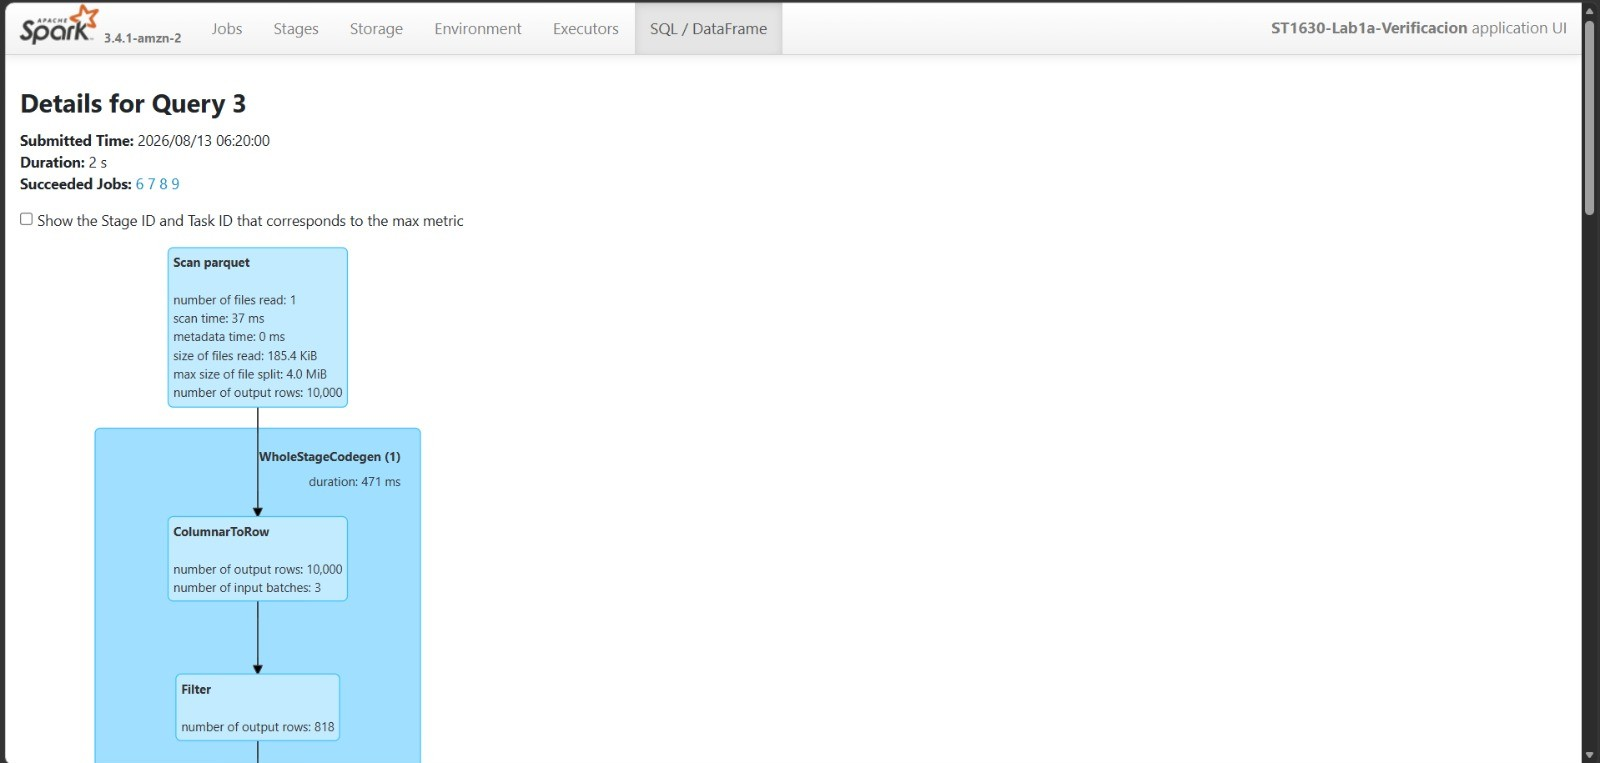

## Bitácora de delegación

Completa según lo que realmente delegaste a un agente de IA durante
este notebook (ver `../../../docs/politica-ia.md`).

| Tarea | ¿Delegado a agente? | Herramienta | Justificación |
|---|---|---|---|
| Boilerplate de SparkSession / lectura de S3 | No | — | El código de las Celdas 2 y 3 venía ya escrito en el repositorio del curso. Lo único que editamos fue la variable `BUCKET`. No lo escribimos nosotros ni un agente. |
| Diseño de la consulta del benchmark (Celda 3) | No | — | La consulta (`filter` + `groupBy` + `agg` + `orderBy`) también venía dada en la plantilla del notebook. |
| Interpretación de los resultados (Celda 4) | Parcial | Claude Code | Las respuestas (a)-(d) las razonamos y redactamos nosotros. Lo delegado fue acotado: el agente aportó el tamaño de los objetos en S3, y ante el ratio invertido (CSV más rápido que Parquet) señaló tres frentes a revisar para la pregunta (c) —el orden en que corren los dos benchmarks, el tamaño del dataset frente al overhead fijo de scheduling, y el reparto del tiempo según el Spark UI— sin dar la conclusión. Las hipótesis que finalmente sostenemos en (c) y el razonamiento de (d) son del equipo. |
| Troubleshooting de errores de conexión a S3 | Sí | Claude Code | Fue lo más delegado de todo el notebook. El primer intento falló con `UnsupportedFileSystemException: No FileSystem for scheme "s3"` porque se estaba ejecutando contra un kernel local y no contra el clúster. El agente diagnosticó la causa (el esquema `s3://` lo implementa EMRFS, que solo existe dentro de EMR), montó Jupyter sobre el nodo master vía túnel SSH, corrigió el `PYTHONPATH` de py4j, y detectó que la sesión se estaba registrando como `PySparkShell` en vez de `ST1630-Lab1a-Verificacion`. El README marca el troubleshooting de conexión a S3 como delegable. |

> Recuerda: la interpretación de los resultados y la conexión con CAP
> (pregunta d) deben reflejar tu propio razonamiento — ver
> `../README.md`, sección "Bitácora de delegación".
